# 1. Data Processing 

In [1]:
import torch.nn as nn                             
import torch.optim as optim                       
import torchvision                                 
import torchvision.models as models                
import torchvision.transforms as transforms       
from torch.utils.data import random_split          
from torch.utils.data.dataloader import DataLoader 
from torchvision.utils import make_grid            
import torch
import PIL.Image as Image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # if GPU not available use CPU
print(device)

cuda:0


In [2]:
my_trans = transforms.Compose([transforms.Resize((400,400)),
                                 transforms.RandomHorizontalFlip(),               # Horizontal flip
                                 transforms.RandomRotation(15),               # Random Rotation by 15 degrees
                                 transforms.ToTensor(), # convert image to tensor
                                 transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                                 ])   # Normalise the tensor

In [3]:
dataset = torchvision.datasets.ImageFolder(root='./pkm_6classes/dataset', transform = my_trans)
print(dataset.class_to_idx)
pkm_names = list(dataset.class_to_idx.keys())
print(pkm_names)

{'bulbasaur': 0, 'charmander': 1, 'gengar': 2, 'mewtwo': 3, 'pikachu': 4, 'squirtle': 5}
['bulbasaur', 'charmander', 'gengar', 'mewtwo', 'pikachu', 'squirtle']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 400, 400])
Label (numeric): 4
Label (textual): pikachu


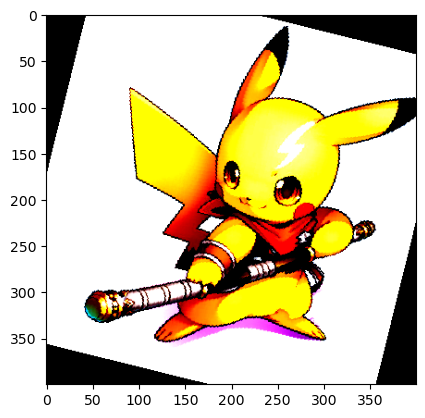

In [4]:
import matplotlib.pyplot as plt
img, label = dataset[233+238+48+239+234-1]  # Taking a single instance
print(img.shape)         # print shape
plt.imshow(img.permute((1, 2, 0))) # plot image
print('Label (numeric):', label)
print('Label (textual):', pkm_names[label])


In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# 2. Load Model

In [6]:
from torchvision.models import vgg16, VGG16_Weights
model_pre = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print(model_pre)

for param in model_pre.parameters():
    param.requires_grad = False

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [7]:
model_pre.classifier[6] = nn.Sequential(
    nn.Linear(4096, 1024), 
    nn.ReLU(), 
    nn.Linear(1024, 256), 
    nn.ReLU(), 
    #nn.Dropout(0.4),
    nn.Linear(256, 6) # 6 classes
)


print(model_pre)
model_pre = model_pre.to(device)
model_pre = torch.load("./vgg_pkm_best.model", weights_only=False)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# 3. Classification on Testing Dataset

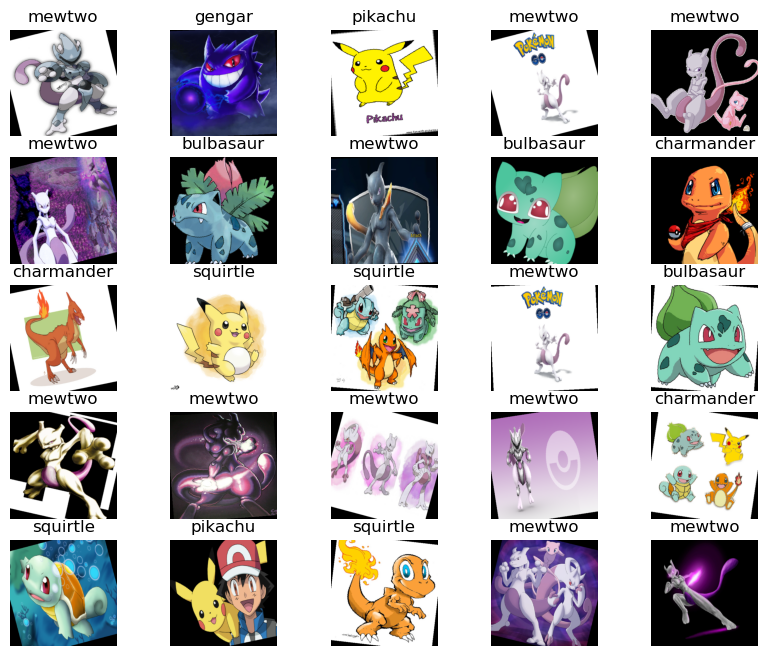

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00]],

        [[2.9802e-08, 2.9802e-08, 2.9802e-08,  ..., 2.9802e-08,
          2.9802e-08, 2.9802e-08],
         [2.9802e-08, 2.9802e-08, 2.9802e-08,  ..., 2.9802e-08,
          2.9802e-08, 2.9802e-08],
         [2.9802e-08, 2.9802e-08, 2.9802e-08,  ..., 2.9802e-08,
          2.9802e-08, 2.9802e-08],
         ...,
         [2.9802e-08, 2.9802e-08, 2.9802e-08,  ..., 2.9802e-08,
          2.980

In [8]:
invTrans = transforms.Compose([ transforms.Normalize(mean = [ 0., 0., 0. ],
                                                     std = [ 1/0.229, 1/0.224, 1/0.225 ]),
                                transforms.Normalize(mean = [ -0.485, -0.456, -0.406 ],
                                                     std = [ 1., 1., 1. ]),
                               ])

figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
    img = test_dataset[sample_idx][0]
    figure.add_subplot(rows, cols, i)
    img_gpu = img.to(device)

    img_gpu = torch.unsqueeze(img_gpu, 0) # add a new dimension
    
    yhat = model_pre(img_gpu)
    #print(yhat)
    label_hat = torch.argmax(yhat) # predicted label
    #print(label_hat)
    #img = img.to(device)
    img = invTrans(img)
    plt.title(pkm_names[label_hat.data.item()])
    plt.axis("off")
    plt.imshow(img.squeeze().permute((1, 2, 0)))
plt.show()
img.squeeze()

# 4. Classification on New Dataset

In [9]:
my_trans2 = transforms.Compose([transforms.Resize((400,400)),
                                 transforms.ToTensor(), # convert image to tensor
                                 transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])   # Normalise the tensor
dataset2 = torchvision.datasets.ImageFolder(root='./pkm_6classes/Test_images', transform = my_trans2)
loader2 = DataLoader(dataset2, batch_size = len(dataset2), shuffle=False, num_workers = 1)


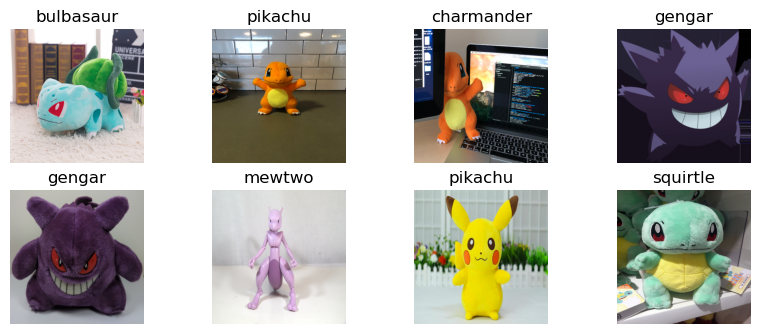

In [11]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 4, 4
for i in range(1, len(dataset2) + 1):
    #sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
    img = dataset2[i-1][0]
    figure.add_subplot(rows, cols, i)
    img_gpu = img.to(device)
    img_gpu = torch.unsqueeze(img_gpu, 0) # add a new dimension
    yhat = model_pre(img_gpu)
    #print(yhat)
    label_hat = torch.argmax(yhat) # predicted label
    #print(label_hat)
    #img = img.to(device)
    img = invTrans(img)
    plt.title(pkm_names[label_hat.data.item()])
    plt.axis("off")
    plt.imshow(img.squeeze().permute((1, 2, 0)))
plt.show()
